# Pommerman FFA Baselines

Train and evaluate practical baseline policies for full four-agent Pommerman FFA. The defaults are smoke-test sized; increase `N_EPISODES` for meaningful learning curves.


In [1]:
from pathlib import Path
import sys


def _find_repo_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for path in (current, *current.parents):
        if (path / "discrete_action_space").exists() and (path / "relevant_papers").exists():
            return path
    raise RuntimeError(f"Could not find repo root from {current}")

ROOT = _find_repo_root()
for path in (ROOT, ROOT / "discrete_action_space", ROOT / "discrete_action_space" / "bimatrix_game"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from discrete_action_space.pommerman_ffa.notebook_utils import (
    display_evaluation_rollout,
    display_training_reward_plots,
    evaluate_policy,
    evaluate_random_reference,
    evaluate_simple_agent_reference,
    policy_from_iql,
    policy_from_ippo,
    train_iql_dqn,
    train_ippo,
)

POMMERMAN_DIR = ROOT / "discrete_action_space" / "pommerman_ffa"

N_EPISODES = 5000
MAX_STEPS = 200
EVAL_EPISODES = 50
EVAL_VIDEO_FPS = 4
BATCH_SIZE = 128
SEED = 2025
USE_GPU = True
OUTPUT_ROOT = POMMERMAN_DIR / "runs" / "baselines"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)


## Built-In SimpleAgent Evaluation

Run fresh evaluation episodes, show the first rollout video if rendering returns frames, then plot one reward boxplot with one box per agent.

pommerman:evaluate:simple_agent:   0%|                                                           | 0/50 [00:00<?, ?it/s]/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/gym/utils/passive_env_checker.py:225: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(done, (bool, np.bool8)):
pommerman:evaluate:simple_agent: 100%|██████████████████████████████████████████████████| 50/50 [00:52<00:00,  1.05s/it]


/home/wowthecoder/SRE-DQN/discrete_action_space/pommerman_ffa/runs/baselines/simple_agent/simple_agent_rollout.gif

[rollout video saved: /home/wowthecoder/SRE-DQN/discrete_action_space/pommerman_ffa/runs/baselines/simple_agent/simple_agent_rollout.gif]


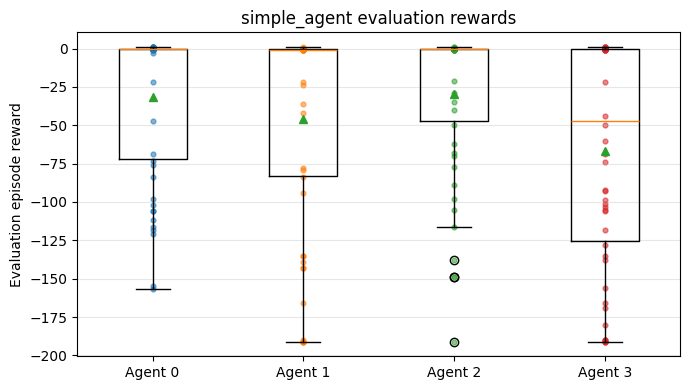

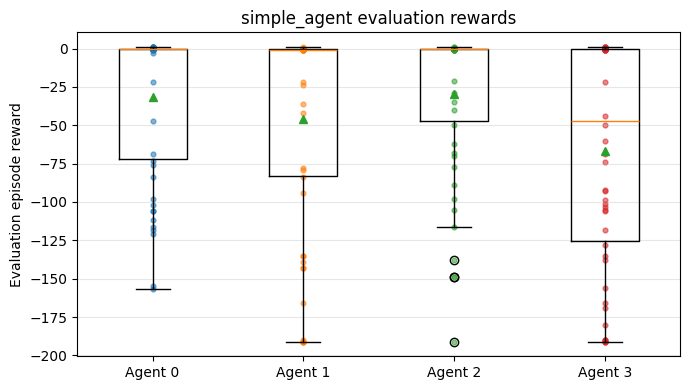

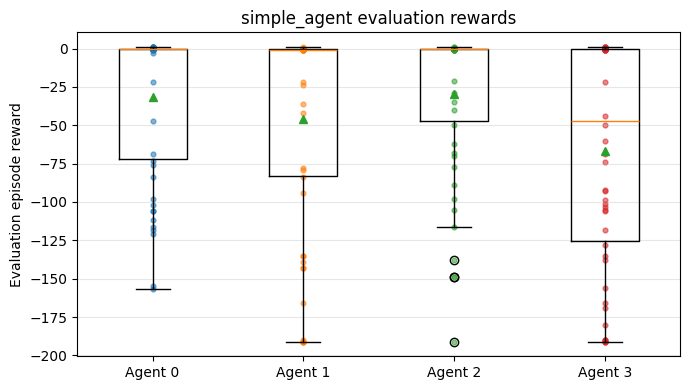

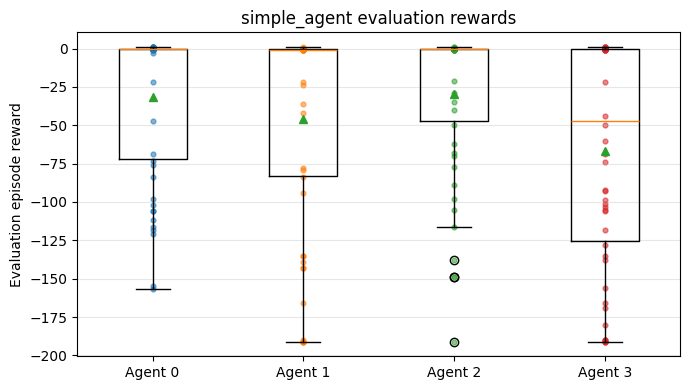

In [2]:
simple_eval = evaluate_simple_agent_reference(
    n_episodes=EVAL_EPISODES,
    max_steps=MAX_STEPS,
    seed=SEED + 2000,
    output_dir=OUTPUT_ROOT / "simple_agent",
)
display_evaluation_rollout(simple_eval, fps=EVAL_VIDEO_FPS)


## Shared-Parameter IQL/DQN Training

In [3]:
iql_stats = train_iql_dqn(
    n_episodes=N_EPISODES,
    max_steps=MAX_STEPS,
    seed=SEED,
    output_root=OUTPUT_ROOT,
    use_gpu=USE_GPU,
    batch_size=BATCH_SIZE,
)


pommerman:iql_dqn:   0%|                                                                       | 0/5000 [00:00<?, ?it/s]/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/gym/utils/passive_env_checker.py:225: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(done, (bool, np.bool8)):
pommerman:iql_dqn: 100%|████████████████████████████████████████████████████████████| 5000/5000 [11:18<00:00,  7.37it/s]


## Shared-Parameter IQL/DQN Training Reward Plots

One scatter plot per agent with mean/std, followed by one combined agent reward curve.

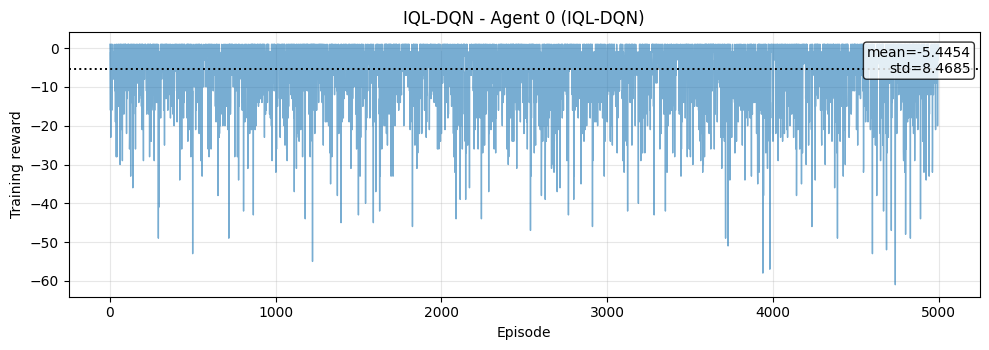

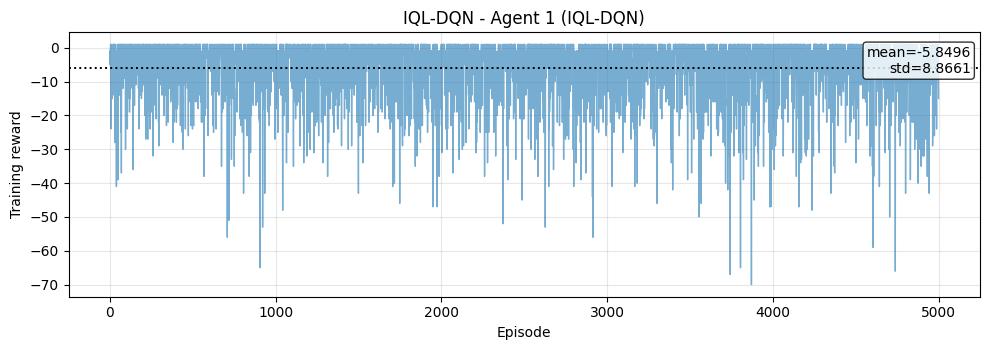

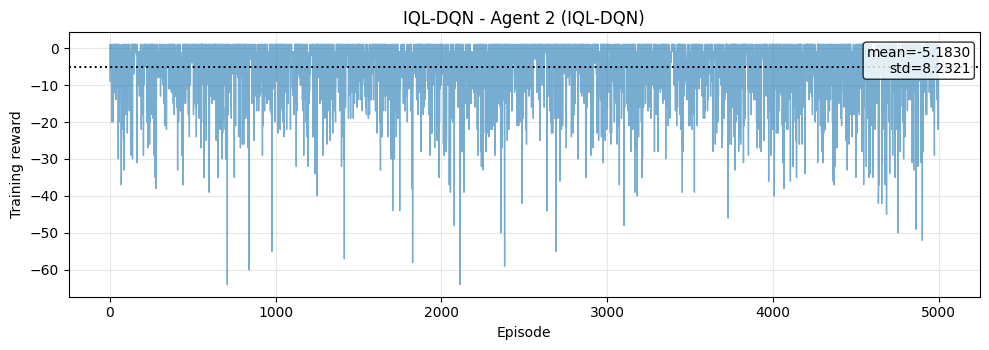

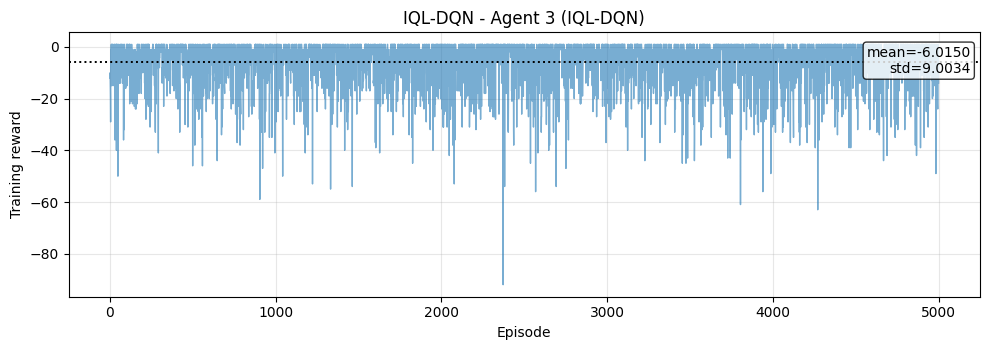

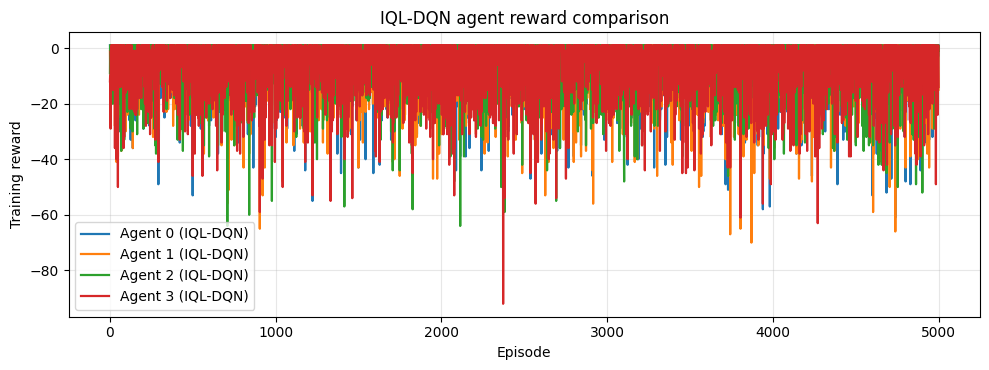

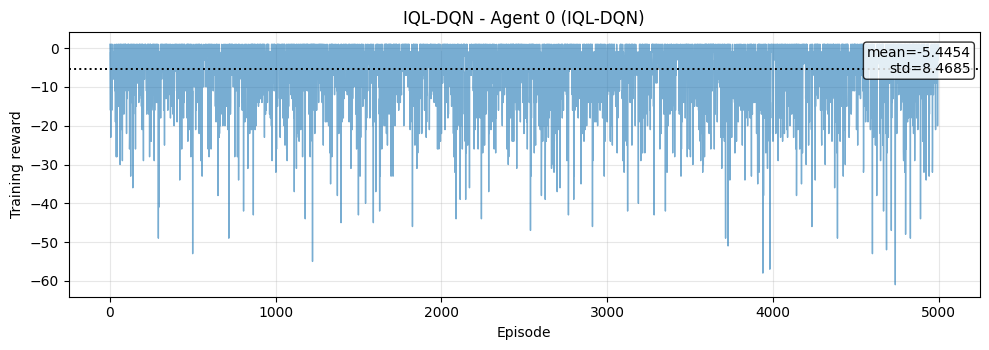

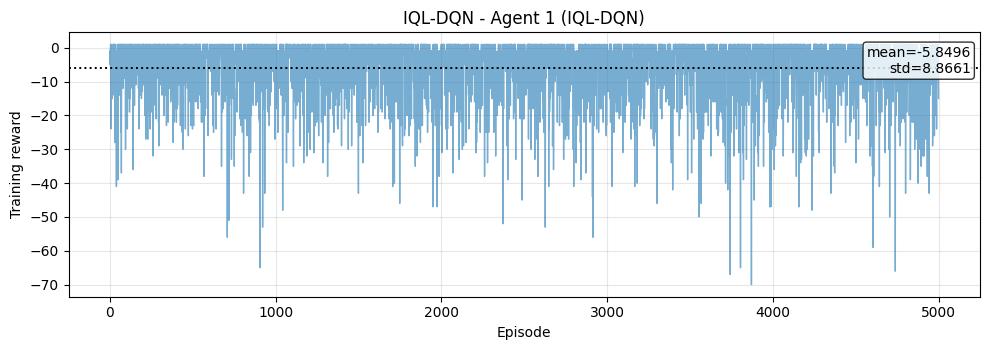

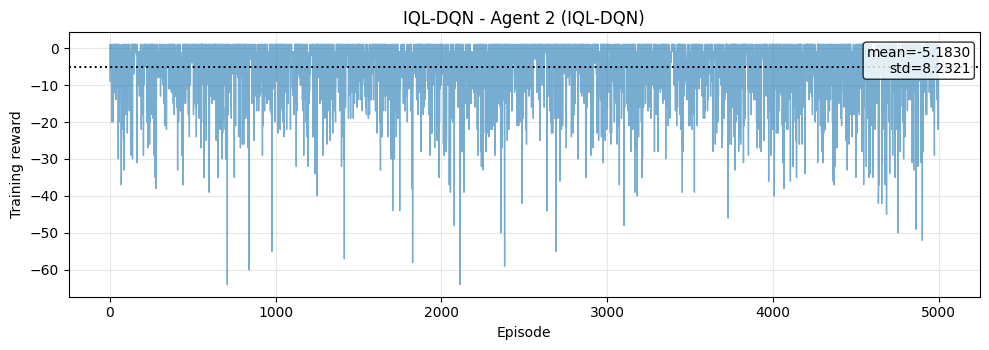

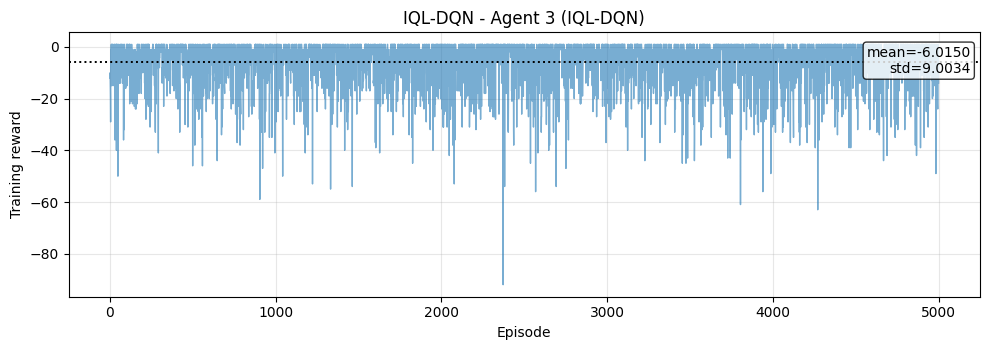

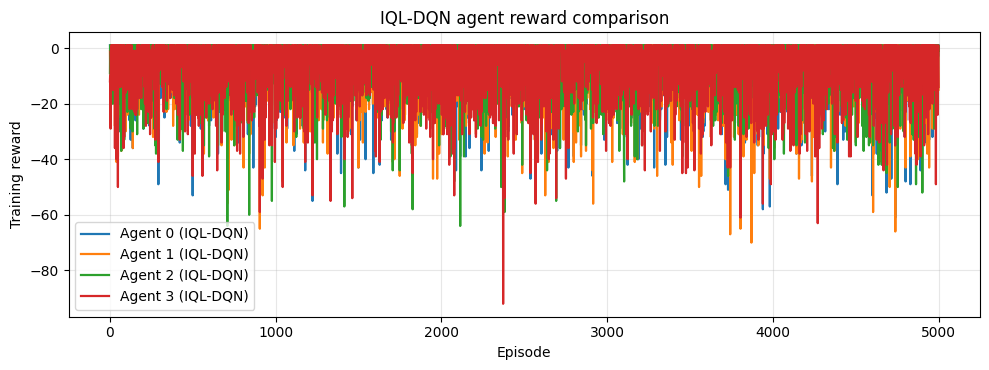

In [4]:
iql_training_figs = display_training_reward_plots(iql_stats)


## Shared-Parameter IQL/DQN Evaluation

Run the trained policy for `EVAL_EPISODES`, show the first rollout video if possible, then plot one boxplot with each agent reward distribution.

pommerman:evaluate:iql_dqn: 100%|███████████████████████████████████████████████████████| 50/50 [00:26<00:00,  1.91it/s]


/home/wowthecoder/SRE-DQN/discrete_action_space/pommerman_ffa/runs/baselines/iql_dqn/iql_dqn_rollout.gif

[rollout video saved: /home/wowthecoder/SRE-DQN/discrete_action_space/pommerman_ffa/runs/baselines/iql_dqn/iql_dqn_rollout.gif]


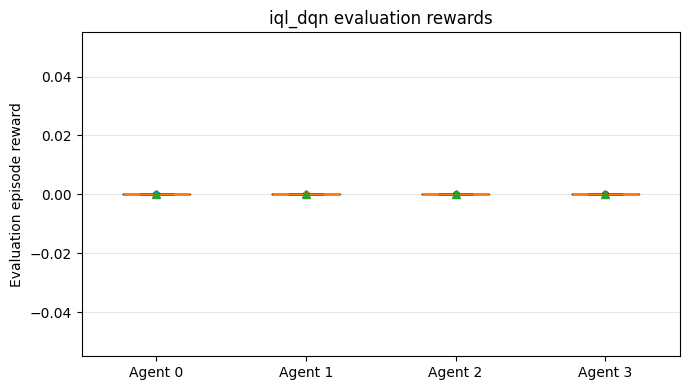

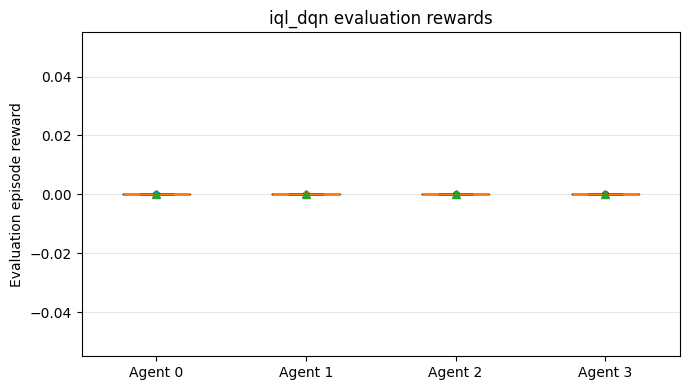

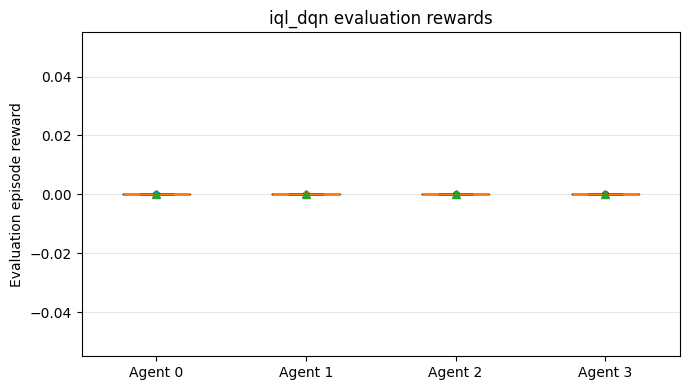

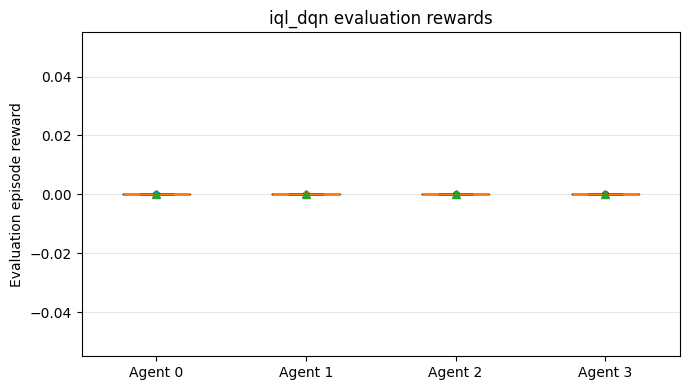

In [5]:
iql_eval = evaluate_policy(
    policy_from_iql(iql_stats["agent"]),
    n_episodes=EVAL_EPISODES,
    max_steps=MAX_STEPS,
    seed=SEED + 3000,
    output_dir=OUTPUT_ROOT / "iql_dqn",
    label="iql_dqn",
)
display_evaluation_rollout(iql_eval, fps=EVAL_VIDEO_FPS)


## Shared-Parameter IPPO/PPO Training

In [6]:
ippo_stats = train_ippo(
    n_episodes=N_EPISODES,
    max_steps=MAX_STEPS,
    seed=SEED + 10,
    output_root=OUTPUT_ROOT,
    use_gpu=USE_GPU,
    batch_size=BATCH_SIZE,
)


pommerman:ippo:   0%|                                                                          | 0/5000 [00:00<?, ?it/s]/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/gym/utils/passive_env_checker.py:225: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(done, (bool, np.bool8)):
pommerman:ippo: 100%|███████████████████████████████████████████████████████████████| 5000/5000 [55:40<00:00,  1.50it/s]


## Shared-Parameter IPPO/PPO Training Reward Plots

One scatter plot per agent with mean/std, followed by one combined agent reward curve.

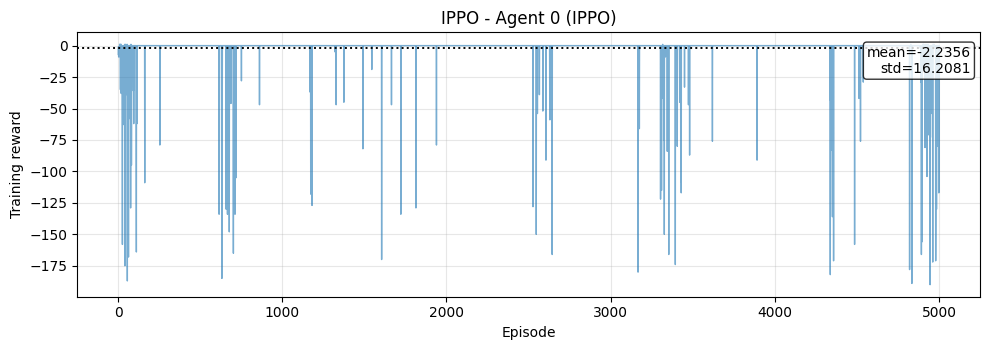

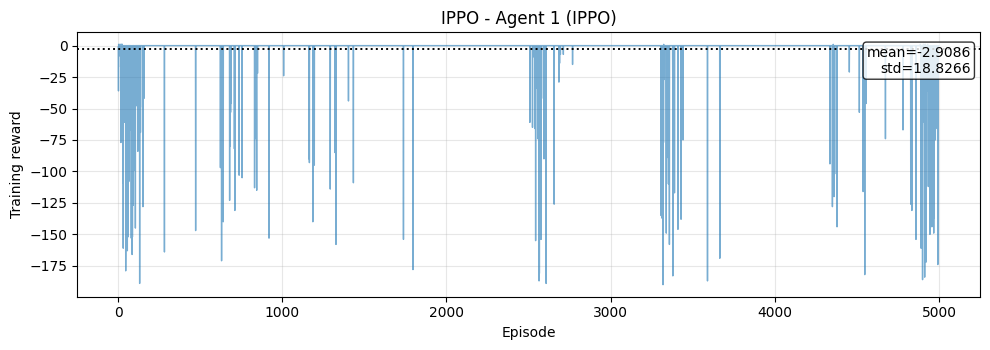

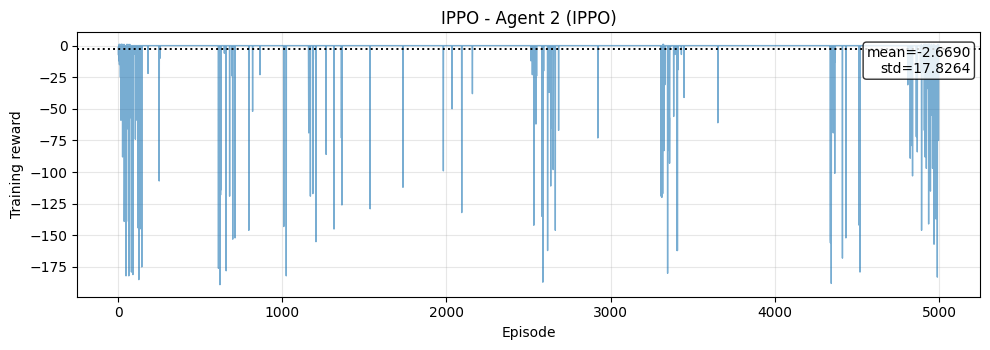

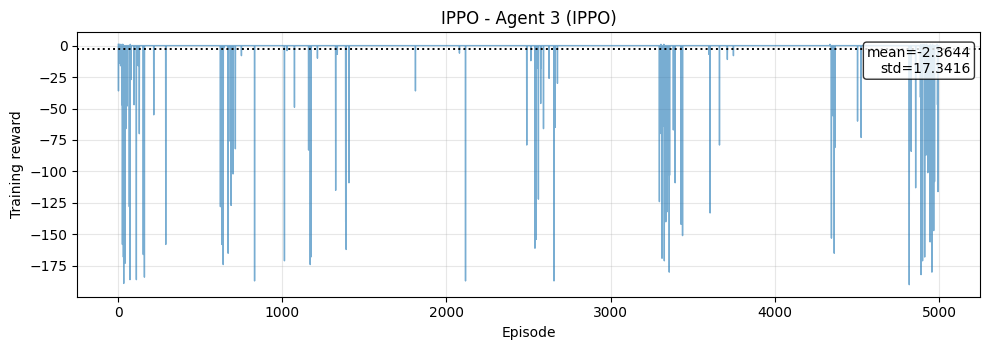

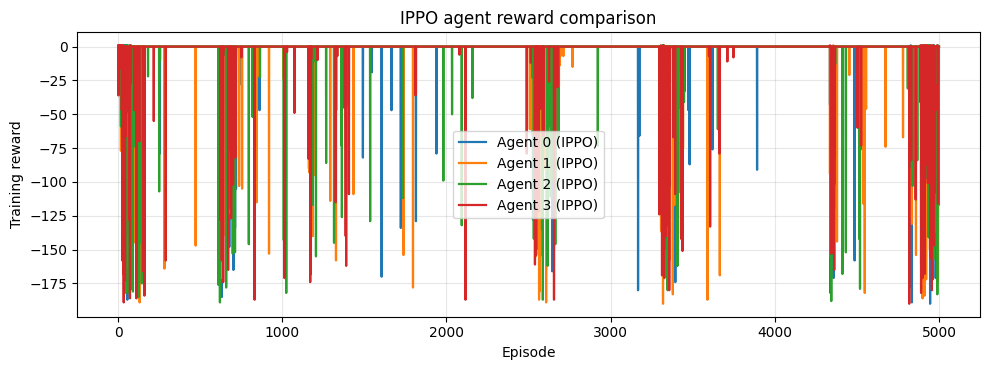

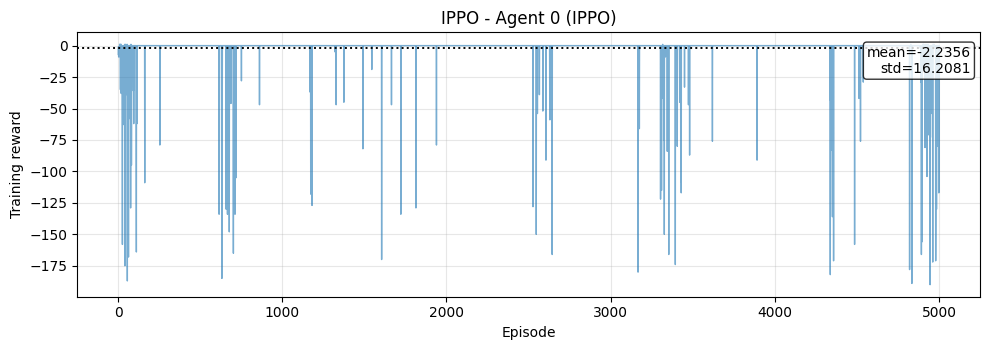

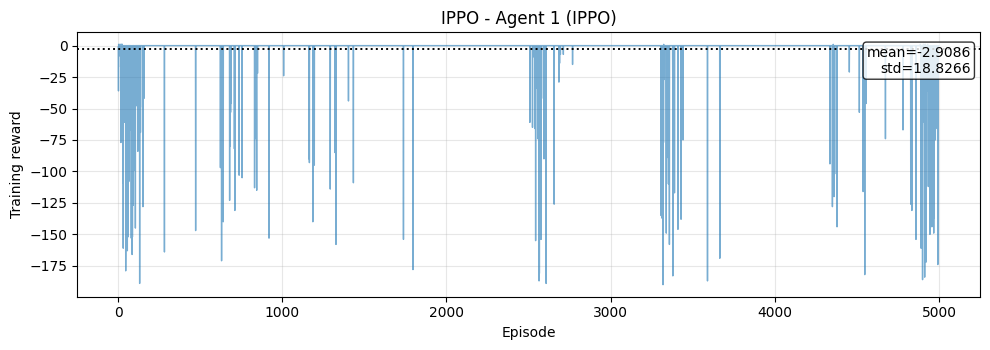

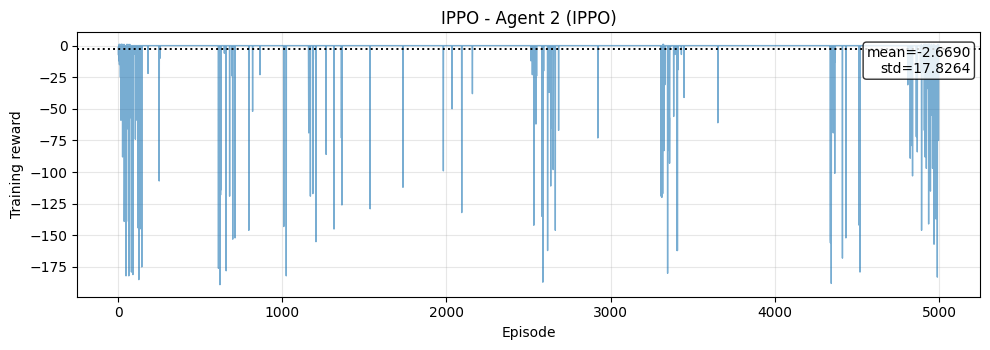

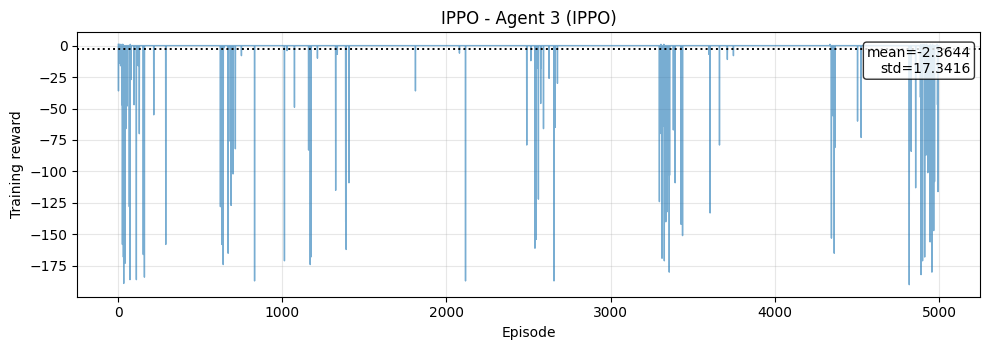

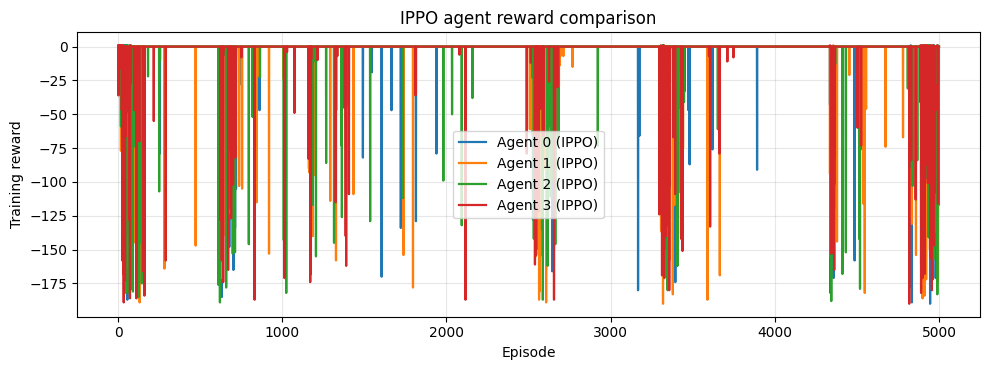

In [7]:
ippo_training_figs = display_training_reward_plots(ippo_stats)


## Shared-Parameter IPPO/PPO Evaluation

Run the trained policy for `EVAL_EPISODES`, show the first rollout video if possible, then plot one boxplot with each agent reward distribution.

pommerman:evaluate:ippo: 100%|██████████████████████████████████████████████████████████| 50/50 [01:16<00:00,  1.54s/it]


/home/wowthecoder/SRE-DQN/discrete_action_space/pommerman_ffa/runs/baselines/ippo/ippo_rollout.gif

[rollout video saved: /home/wowthecoder/SRE-DQN/discrete_action_space/pommerman_ffa/runs/baselines/ippo/ippo_rollout.gif]


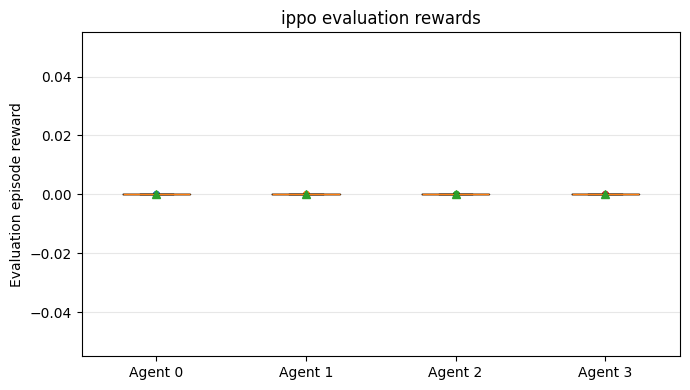

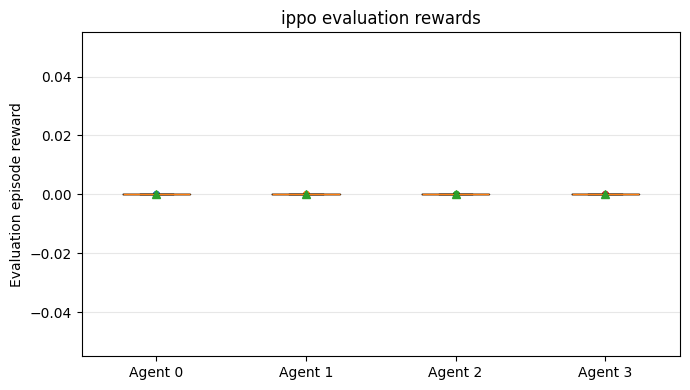

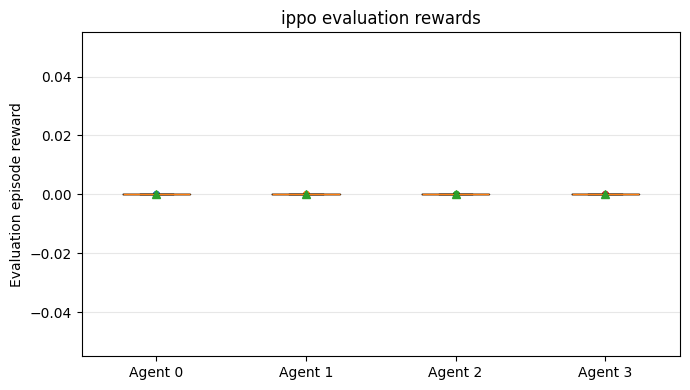

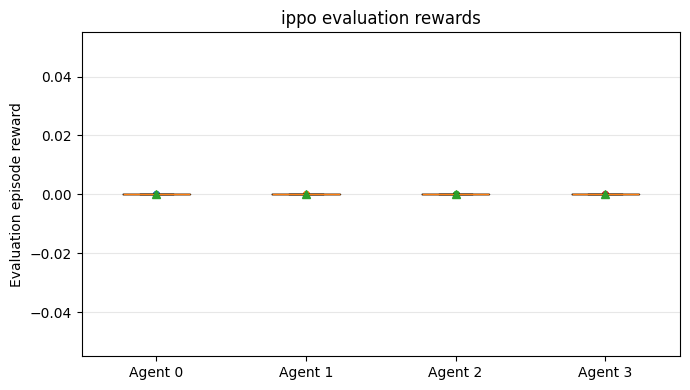

In [8]:
ippo_eval = evaluate_policy(
    policy_from_ippo(ippo_stats["agent"]),
    n_episodes=EVAL_EPISODES,
    max_steps=MAX_STEPS,
    seed=SEED + 4000,
    output_dir=OUTPUT_ROOT / "ippo",
    label="ippo",
)
display_evaluation_rollout(ippo_eval, fps=EVAL_VIDEO_FPS)
